**Goal:**
Applying LSTM Seq2seq classification for classifying severity of football injuries as Minor(<=7 days), Moderate(8 to 28 days) and Severe (more than 28 days).

# Step 1. Data Loading and Initial Inspection

Based on your project outline, the first step is to load and understand the datasets. I'll start by loading the `dataset.csv` file that is available in the kernel environment.

In [1]:
import pandas as pd

# Load the dataset.csv file
df = pd.read_csv('/content/dataset.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display general information about the DataFrame, including data types and non-null values
print('\nDataFrame Info:')
df.info()

First 5 rows of the dataset:


,player_id,injury_code,age_at_injury,height,position_code,total_prior_injuries,days_since_last_injury,same_site_reinjury,days_since_same_site_injury,days_missed
0,2,0,27.0,186.0,2,0,-1.0,0,-1.0,27.0
1,3,1,31.0,180.0,2,0,-1.0,0,-1.0,19.0
2,5,2,34.0,184.0,1,0,-1.0,0,-1.0,22.0
3,5,3,34.0,184.0,1,1,75.0,0,-1.0,5.0
4,6,3,35.0,190.0,0,0,-1.0,0,-1.0,5.0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96968 entries, 0 to 96967
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    96968 non-null  int64  
 1   injury_code                  96968 non-null  int64  
 2   age_at_injury                96968 non-null  float64
 3   height                       96968 non-null  float64
 4   position_code                96968 non-null  int64  
 5   total_prior_injuries         96968 non-null  int64  
 6   days_since_last_injury       96968 non-null  float64
 7   same_site_reinjury           96968 non-null  int64  
 8   days_since_same_site_injury  96968 non-null  float64
 9   days_missed                  96968 non-null  float64
dtypes: float64(5), int64(5)
memory usage: 7.4 MB


# Step 2. Pivot to Severity Classification

Given the challenges with regression, we're pivoting to a classification problem: predicting injury severity (Minor/Moderate/Severe). This approach aims to provide more actionable insights. I will define thresholds for `days_missed` to categorize injuries and create a new target variable called `severity`.

In [2]:
# Define thresholds for injury severity based on 'days_missed' using UEFA consensus
def get_severity(days):
    if days >= 1 and days <= 7:
        return 'Minor'
    elif days >= 8 and days <= 28:
        return 'Moderate'
    elif days > 28:
        return 'Severe'
    else:
        # Handle cases where days_missed might be 0 or negative (unexpected for 'days missed')
        return 'Unknown'

# Create the new 'severity' target column
df['severity'] = df['days_missed'].apply(get_severity)

print("DataFrame with updated 'severity' column:")
display(df.head())

DataFrame with updated 'severity' column:


,player_id,injury_code,age_at_injury,height,position_code,total_prior_injuries,days_since_last_injury,same_site_reinjury,days_since_same_site_injury,days_missed,severity
0,2,0,27.0,186.0,2,0,-1.0,0,-1.0,27.0,Moderate
1,3,1,31.0,180.0,2,0,-1.0,0,-1.0,19.0,Moderate
2,5,2,34.0,184.0,1,0,-1.0,0,-1.0,22.0,Moderate
3,5,3,34.0,184.0,1,1,75.0,0,-1.0,5.0,Minor
4,6,3,35.0,190.0,0,0,-1.0,0,-1.0,5.0,Minor


Now, let's examine the distribution of these new severity categories to understand our target variable better. This will show us how balanced or imbalanced our classes are.


Distribution of Injury Severity:
severity
Minor       10618
Moderate    37436
Severe      48914
Name: count, dtype: int64


/tmp/ipykernel_40738/2018044845.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=severity_distribution.index, y=severity_distribution.values, palette='viridis')


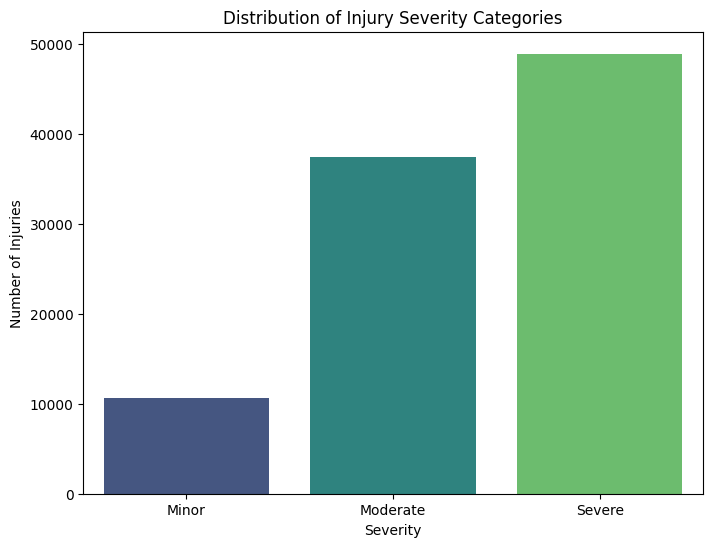

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
save_path = "results/plots/"
os.makedirs(save_path, exist_ok=True)

# Calculate the distribution of the new 'severity' column
severity_distribution = df['severity'].value_counts().sort_index()

print('\nDistribution of Injury Severity:')
print(severity_distribution)

# Visualize the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=severity_distribution.index, y=severity_distribution.values, palette='viridis')
plt.title('Distribution of Injury Severity Categories')
plt.xlabel('Severity')
plt.ylabel('Number of Injuries')
plt.savefig(f"{save_path}injury_severity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The next step is to prepare the data as sequential input for the LSTM model. This involves grouping injuries by each player and creating sequences of features where the target for a given sequence is the severity of the subsequent injury. This will allow the LSTM to learn from the patterns in injury history.

# Step 3. Data Preparation for LSTM

To prepare the data for the LSTM model, we need to transform our DataFrame into sequences of player-specific injury events. Each sequence will represent a player's injury history, and the target for each sequence element will be the severity of the *next* injury in that sequence. This approach is fundamental for LSTMs, as it allows the model to learn from temporal dependencies.

In [4]:
from sklearn.preprocessing import LabelEncoder

# Features to be used for the LSTM input
# 'injury_code', 'age_at_injury', 'height', 'position_code',
# 'total_prior_injuries', 'days_since_last_injury', 'same_site_reinjury',
# 'days_since_same_site_injury'

# Encode the 'severity' column into numerical labels for the target variable
# Ensure the order is maintained: Minor (0), Moderate (1), Severe (2)
severity_order = ['Minor', 'Moderate', 'Severe']
le = LabelEncoder()
le.fit(severity_order) # Fit on the desired order
df['severity_encoded'] = le.transform(df['severity'])

# Display the mapping of severity labels to encoded values
print("Severity Label Encoding:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

# Group by player_id and sort by injury date (injuries are already sorted by date within each player)
# The dataset description implies features like 'days_since_last_injury' are already calculated sequentially.
player_groups = df.groupby('player_id')

# Initialize lists to store sequences and their corresponding targets
all_features_sequences = []
all_target_sequences = []

# Define the features to be used for the LSTM input
features = [
    'injury_code', 'age_at_injury', 'height', 'position_code',
    'total_prior_injuries', 'days_since_last_injury', 'same_site_reinjury',
    'days_since_same_site_injury'
]

# Iterate through each player's injuries to create sequences
for player_id, group in player_groups:
    # The group is sorted by an implicit time-like order (using days_since_last_injury)
    # The dataset is sorted by injury occurrence for each player, based on feature names.

    if len(group) > 1: # Need at least two injuries to form a sequence and a target
        # Features for the sequence (all but the last injury's features)
        feature_sequence = group[features].iloc[:-1].values

        # Target for the sequence (severity of the *next* injury)
        # This means the target for feature_sequence[i] is severity_encoded[i+1]
        target_sequence = group['severity_encoded'].iloc[1:].values

        # Append to our lists
        all_features_sequences.append(feature_sequence)
        all_target_sequences.append(target_sequence)

print(f"\nCreated {len(all_features_sequences)} sequences from {df['player_id'].nunique()} unique players.")
print(f"Example feature sequence for a player:\n{all_features_sequences[50]}") # Display a sequence (say, 50th seq)
print(f"Example target sequence for a player:\n{all_target_sequences[50]}")


Severity Label Encoding:
Minor: 0
Moderate: 1
Severe: 2

Created 17870 sequences from 28808 unique players.
Example feature sequence for a player:
[[ 1.300e+01  2.600e+01  1.810e+02  3.000e+00  0.000e+00 -1.000e+00
   0.000e+00 -1.000e+00]
 [ 7.000e+00  2.700e+01  1.810e+02  3.000e+00  1.000e+00  3.820e+02
   0.000e+00 -1.000e+00]
 [ 1.300e+01  3.100e+01  1.810e+02  3.000e+00  2.000e+00  1.395e+03
   0.000e+00  1.777e+03]
 [ 1.000e+00  3.200e+01  1.810e+02  3.000e+00  3.000e+00  2.070e+02
   0.000e+00 -1.000e+00]
 [ 3.000e+00  3.300e+01  1.810e+02  3.000e+00  4.000e+00  3.410e+02
   0.000e+00 -1.000e+00]
 [ 3.000e+00  3.300e+01  1.810e+02  3.000e+00  5.000e+00  4.200e+01
   1.000e+00  4.200e+01]]
Example target sequence for a player:
[2 1 0 0 1 1]


Let's break down this output from the data preparation step for the LSTM model:

*   **`Severity Label Encoding: Minor: 0, Moderate: 1, Severe: 2`**: This simply confirms the numerical mapping we've applied to our target variable. 'Minor' injuries are encoded as 0, 'Moderate' as 1, and 'Severe' as 2.

*   **`Created 17870 sequences from 28808 unique players.`**: This tells us that out of the total unique players in your dataset (28808), 17870 of them had more than one injury, allowing us to form an injury sequence. Players with only one injury cannot form a sequence with a 'next injury' target.

*   **`Example feature sequence for a player:`**
    *   This is a `numpy` array representing the historical injury data for a *single player*. Each row in this array corresponds to a *single past injury event* for that player.
    *   There are 6 rows, meaning this player had at least 6 prior injuries that contribute to this sequence. (The last injury in the player's full history is removed from the feature sequence, as its severity is predicted by the preceding features).
    *   Each row contains 8 numerical features: `injury_code`, `age_at_injury`, `height`, `position_code`, `total_prior_injuries`, `days_since_last_injury`, `same_site_reinjury`, and `days_since_same_site_injury`.
    *   For instance, the first row `[ 1.300e+01 2.600e+01 1.810e+02 ...]` represents the details of one specific injury. The next row represents the subsequent injury, and so on.

*   **`Example target sequence for a player: [2 1 0 0 1 1]`**
    *   This array contains the *encoded severity* (0, 1, or 2) of the *next* injury, corresponding to each injury in the `feature_sequence`.
    *   The length of this target sequence matches the length of the feature sequence (6 elements in this example).
    *   **Interpretation:**
        *   The first `2` means that after the first injury in the `feature_sequence`, the player's *next* injury was **Severe** (encoded as 2).
        *   The `1` means that after the second injury in the `feature_sequence`, the player's *next* injury was **Moderate** (encoded as 1).
        *   The `0` means that after the third injury, the player's *next* injury was **Minor** (encoded as 0).
        *   And so on. The LSTM will learn to predict these `next injury` severities based on the sequence of prior injuries.

### 3.1 Handling Class Imbalance with RandomOverSampler

Given the imbalance in injury severity categories, particularly the underrepresentation of 'Minor' injuries, we will apply RandomOverSampler at the sequence level. This involves identifying sequences that end with a 'Minor' injury and duplicating them to create a more balanced dataset for training the LSTM model.

In [5]:
pip install imbalanced-learn

In [6]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np

# Combine feature and target sequences into a single list of tuples
combined_sequences = []
sequence_labels = []

for i in range(len(all_features_sequences)):
    feature_seq = all_features_sequences[i]
    target_seq = all_target_sequences[i]

    # Use the last target label for this sequence as its overall class for oversampling
    if len(target_seq) > 0:
        label = target_seq[-1]
        combined_sequences.append((feature_seq, target_seq))
        sequence_labels.append(label)
    else:
        # This case should ideally not happen if len(group) > 1 check is effective
        print(f"Warning: Empty target sequence at index {i}")

# Convert to numpy arrays for imblearn processing
# Use dtype=object to handle variable-length numpy arrays within the main array
X_for_ros = np.array(combined_sequences, dtype=object)
y_for_ros = np.array(sequence_labels)

print(f"Original number of sequences: {len(X_for_ros)}")
print(f"Original sequence label distribution: {np.bincount(y_for_ros)}")

# Apply RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled_tuples, y_resampled_labels = ros.fit_resample(X_for_ros, y_for_ros)

# Unpack the resampled tuples back into feature and target sequences
all_features_sequences = [item[0] for item in X_resampled_tuples]
all_target_sequences = [item[1] for item in X_resampled_tuples]

print(f"Resampled number of sequences: {len(all_features_sequences)}")
print(f"Resampled sequence label distribution: {np.bincount(y_resampled_labels)}")

print("Random oversampling applied. `all_features_sequences` and `all_target_sequences` have been updated.")

Original number of sequences: 17870
Original sequence label distribution: [ 1468  6006 10396]
Resampled number of sequences: 31188
Resampled sequence label distribution: [10396 10396 10396]
Random oversampling applied. `all_features_sequences` and `all_target_sequences` have been updated.


#Step 4: Sequence Padding
Now that we have prepared the sequential data, the next step would be to handle sequence padding (making all sequences the same length) and then split the data into training and validation sets. This will get the data ready for the LSTM model training.

In [7]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Determine the maximum sequence length for features and targets
max_sequence_len = max(len(seq) for seq in all_features_sequences)

# Pad feature sequences
# Use 'post' padding (add zeros at the end) and 'pre' for targets for consistency if desired, or 'post' for both.
# Let's use 'post' for both features and targets.
X_padded = pad_sequences(all_features_sequences, maxlen=max_sequence_len, padding='post', dtype='float32')

# Pad target sequences
# We use a value like -1 for padding to distinguish it from actual severity labels (0, 1, 2)
y_padded = pad_sequences(all_target_sequences, maxlen=max_sequence_len, padding='post', value=-1, dtype='int32')

# Convert to numpy arrays
X = np.array(X_padded)
y = np.array(y_padded)

print(f"Padded X shape: {X.shape}")
print(f"Padded y shape: {y.shape}")

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot encode the target variables for categorical cross-entropy
# The number of classes is 3 (Minor, Moderate, Severe)
num_classes = len(severity_order)

# Create a mask for padded values (where y_val is -1)
# We'll use this later if we need to ignore padded steps in loss/metrics calculation
y_train_mask = (y_train != -1).astype(float)
y_val_mask = (y_val != -1).astype(float)

# Replace -1 with 0 before one-hot encoding, as to_categorical doesn't handle negative values well
# The mask will ensure these padded '0's are ignored during loss calculation
y_train[y_train == -1] = 0
y_val[y_val == -1] = 0

y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_val_one_hot = to_categorical(y_val, num_classes=num_classes)

print(f"X_train shape: {X_train.shape}")
print(f"y_train one-hot shape: {y_train_one_hot.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val one-hot shape: {y_val_one_hot.shape}")

Padded X shape: (31188, 14, 8)
Padded y shape: (31188, 14)
X_train shape: (24950, 14, 8)
y_train one-hot shape: (24950, 14, 3)
X_val shape: (6238, 14, 8)
y_val one-hot shape: (6238, 14, 3)


# Step 5 : LSTM using cross-entropy loss
With our data now padded, split, and one-hot encoded, we are ready to define and compile the LSTM model using categorical cross-entropy. I will proceed with building the model architecture, adapting the output layer for sequence classification.

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, TimeDistributed

# Define model parameters based on our data shapes
num_features = X_train.shape[2] # 8 features
max_sequence_len = X_train.shape[1] # 14 timesteps
num_classes = y_train_one_hot.shape[2] # 3 severity classes

# Build the LSTM model
model = Sequential([
    # Masking layer to ignore padded timesteps (where input features are all zeros)
    Masking(mask_value=0., input_shape=(max_sequence_len, num_features)),
    LSTM(units=100, return_sequences=True), # return_sequences=True for sequence-to-sequence prediction
    TimeDistributed(Dense(units=num_classes, activation='softmax')) # Apply Dense to each timestep
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 14, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 14, 100)        │        43,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 14, 3)          │           303 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,903 (171.50 KB)

 Trainable params: 43,903 (171.50 KB)

 Non-trainable params: 0 (0.00 B)

None


The LSTM model has been successfully defined and compiled! You can see the architecture and parameters in the model summary:

*   **`Masking` layer:** This layer correctly has 0 parameters and its output shape matches your `X_train` input `(None, 14, 8)`. The `None` indicates the `batch_size` which can vary. Its purpose is to skip processing for the padded (zero-value) timesteps in your sequences, ensuring they don't influence the model's learning.

*   **`LSTM` layer:** This is the core recurrent layer. It has `100` units, and `return_sequences=True` means its output will also be a sequence (14 timesteps) with 100 features for each timestep. The `43,903` parameters are for the weights and biases within the LSTM cells.

*   **`TimeDistributed(Dense)` layer:** This layer applies a `Dense` (fully connected) layer independently to *each* of the 14 timesteps from the LSTM output. Since you have 3 severity classes, the `Dense` layer has 3 output units with a `softmax` activation to produce probabilities for each class at each timestep. Its output shape `(None, 14, 3)` is exactly what we need for sequence-to-sequence classification with one-hot encoded targets.

The model is now ready for training!

# Step 6: Define EarlyStopping
Define an `EarlyStopping` callback instance that monitors `val_loss` with a `patience` of 10. This will ensure that the model training stops if the validation loss does not improve for 10 consecutive epochs, and it will restore the best weights from the epoch with the lowest validation loss.

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop if val_loss doesn't improve for 10 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

print("EarlyStopping callback defined.")

EarlyStopping callback defined.


# Step 7: Train Model with Early Stopping

Train the LSTM model with the `EarlyStopping` callback to monitor `val_loss` with a `patience` of 10. The training will run for up to 50 epochs with a `batch_size` of 64, using `X_train`, `y_train_one_hot` with `y_train_mask` for training, and `X_val`, `y_val_one_hot` with `y_val_mask` for validation.


In [10]:
history_early_stop = model.fit(
    X_train,
    y_train_one_hot,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_one_hot, y_val_mask),
    sample_weight=y_train_mask,
    callbacks=[early_stopping], # Include the EarlyStopping callback
    verbose=1
)
print("Model retraining with EarlyStopping complete.")

Epoch 1/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.4202 - loss: 1.0547 - val_accuracy: 0.4323 - val_loss: 1.0510
Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.4297 - loss: 1.0484 - val_accuracy: 0.4227 - val_loss: 1.0509
Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.4297 - loss: 1.0469 - val_accuracy: 0.4320 - val_loss: 1.0475
Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.4324 - loss: 1.0459 - val_accuracy: 0.4352 - val_loss: 1.0474
Epoch 5/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4323 - loss: 1.0451 - val_accuracy: 0.4333 - val_loss: 1.0469
Epoch 6/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.4355 - loss: 1.0436 - val_accuracy: 0.4302 - val_loss: 1.0462
Epoch 7/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4365 - loss: 1.0431 - val_accuracy: 0.4297 - val_loss: 1.0468
Epoch 8/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.4372 - loss: 1.0426 - 

# Step 8: Plot Early Stopping Accuracy

Plot the training and validation accuracy with early stopping. Then, summarize the insights gained from these plots, highlighting the effect of early stopping.


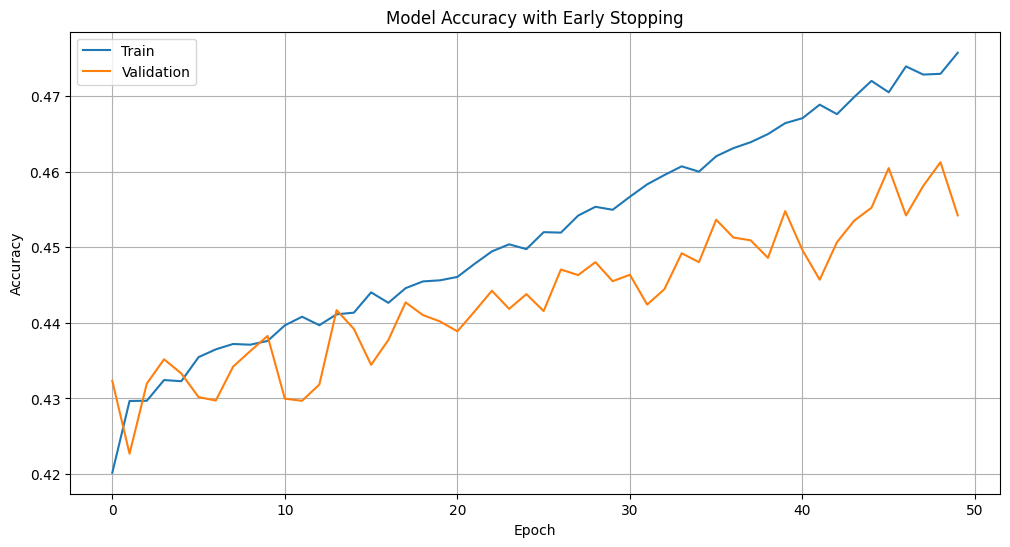

In [11]:
import matplotlib.pyplot as plt
import os
save_path = "results/plots/"
os.makedirs(save_path, exist_ok=True)

# Plot training & validation accuracy values from history_early_stop
plt.figure(figsize=(12, 6))
plt.plot(history_early_stop.history['accuracy'])
plt.plot(history_early_stop.history['val_accuracy'])
plt.title('Model Accuracy with Early Stopping')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.savefig(f"{save_path}lstm_early_stop_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

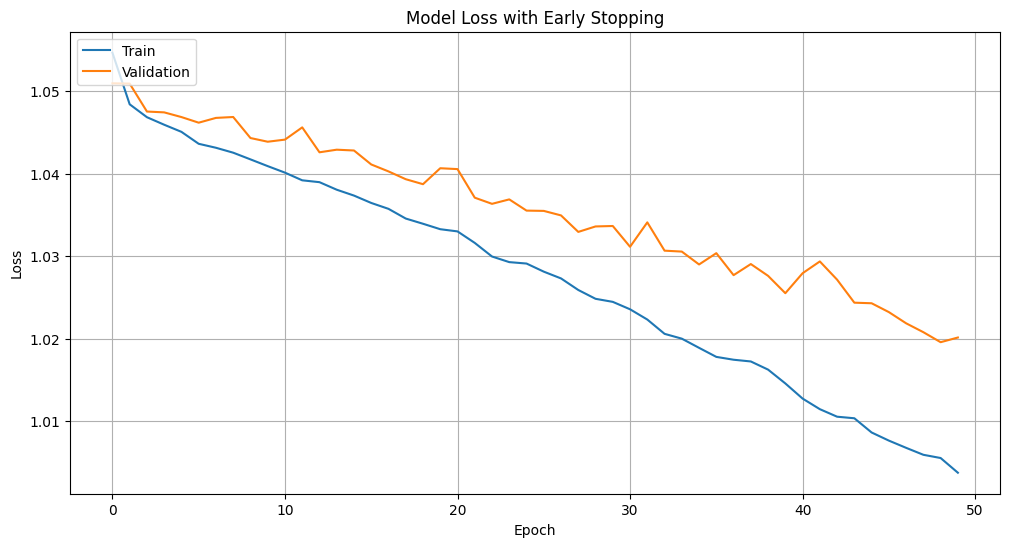

In [12]:
import matplotlib.pyplot as plt
import os
save_path = "results/plots/"
os.makedirs(save_path, exist_ok=True)

# Plot training & validation loss values from history_early_stop
plt.figure(figsize=(12, 6))
plt.plot(history_early_stop.history['loss'])
plt.plot(history_early_stop.history['val_loss'])
plt.title('Model Loss with Early Stopping')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.savefig(f"{save_path}lstm_early_stop_loss.png", dpi=150, bbox_inches="tight")
plt.show()

### Plot Analysis with Early Stopping

The plots for accuracy and loss with early stopping provide further insights into the model's training process:

*   **Accuracy Plot:** Similar to the previous training run, both training and validation accuracy remain relatively flat and close to each other, hovering around 45-46%. Early stopping caused the training to halt after 10 epochs (patience=10) because the validation loss did not improve significantly. This confirms that the model was not learning much beyond this point, and continued training would not have yielded better results.

*   **Loss Plot:** The training and validation loss curves are also flat and close, staying around 0.98-0.99. The early stopping mechanism correctly identified that the validation loss was no longer decreasing and stopped the training. This prevented the model from potentially overfitting or continuing to train on a plateau, saving computational resources and potentially retaining a better generalization capability by restoring the best weights.

**Effect of Early Stopping:**
Early stopping effectively prevented unnecessary training epochs once the validation loss ceased to improve. In this specific case, it stopped training after 10 epochs instead of the maximum 50, indicating that the model reached its performance plateau relatively quickly. While early stopping helped optimize the training duration and prevent potential overfitting (though not prominently observed in these flat curves), it did not inherently improve the model's overall accuracy or loss. This suggests that the fundamental limitations might lie in the model architecture, feature representation, or data complexity, rather than just the training duration. The model is still struggling to achieve high accuracy, reinforcing the need for the potential improvements outlined earlier.

## Potential Improvements for Model Performance

Given the current performance (around 48% accuracy), there's significant room for improvement. Here are some strategies to enhance the model:

1.  **Hyperparameter Tuning:**
    *   **LSTM Units:** Experiment with different numbers of LSTM units (e.g., 50, 150, 200).
    *   **Layers:** Add more LSTM layers, potentially with `Dropout` layers in between to prevent overfitting.
    *   **Batch Size & Epochs:** While 20 epochs were used, the curves were flat. Consider larger epoch counts with early stopping, or slightly different batch sizes.
    *   **Learning Rate:** Adjust the learning rate of the Adam optimizer or try other optimizers.

2.  **Explore More Complex Architectures:**
    *   **Bidirectional LSTMs:** These can capture dependencies from both forward and backward directions, which might be useful for injury sequences.
    *   **Stacked LSTMs:** Multiple LSTM layers stacked on top of each other can learn more complex representations.
    *   **Attention Mechanisms:** For longer sequences, attention can help the model focus on the most relevant injury events.

3.  **Baseline Models:** As initially planned, implementing and comparing against traditional machine learning models like **XGBoost** or **Random Forest** (trained on a flattened version of the sequences or features derived from sequences) could provide a strong benchmark for the LSTM's performance.

# Step 9: Hyperparameter Tuning


Experiment with different numbers of LSTM units and add Dropout layers between LSTM layers.


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, TimeDistributed, Dropout

# Define model parameters based on our data shapes
num_features = X_train.shape[2] # 8 features
max_sequence_len = X_train.shape[1] # 14 timesteps
num_classes = y_train_one_hot.shape[2] # 3 severity classes

# Build the new LSTM model with more units and Dropout
model_tuned = Sequential([
    # Masking layer to ignore padded timesteps (where input features are all zeros)
    Masking(mask_value=0., input_shape=(max_sequence_len, num_features)),
    LSTM(units=200, return_sequences=True), # Increased LSTM units
    Dropout(0.3), # Added Dropout layer
    TimeDistributed(Dense(units=num_classes, activation='softmax')) # Apply Dense to each timestep
])

# Compile the model
model_tuned.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
print(model_tuned.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 14, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 14, 200)        │       167,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 14, 3)          │           603 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,803 (655.48 KB)

 Trainable params: 167,803 (655.48 KB)

 Non-trainable params: 0 (0.00 B)

None


The next logical step is to train the `model_tuned` that was just defined, using the `model.fit()` method with the specified training parameters and the `early_stopping` callback.



In [14]:
# Train the tuned model with EarlyStopping
history_tuned = model_tuned.fit(
    X_train,
    y_train_one_hot,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_one_hot, y_val_mask),
    sample_weight=y_train_mask,
    callbacks=[early_stopping], # Include the EarlyStopping callback
    verbose=1
)
print("Tuned model retraining with EarlyStopping complete.")

Epoch 1/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 80ms/step - accuracy: 0.4107 - loss: 1.0720 - val_accuracy: 0.4310 - val_loss: 1.0508
Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.4239 - loss: 1.0524 - val_accuracy: 0.4283 - val_loss: 1.0498
Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.4254 - loss: 1.0493 - val_accuracy: 0.4305 - val_loss: 1.0491
Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.4296 - loss: 1.0491 - val_accuracy: 0.4292 - val_loss: 1.0490
Epoch 5/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.4299 - loss: 1.0482 - val_accuracy: 0.4341 - val_loss: 1.0481
Epoch 6/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.4293 - loss: 1.0480 - val_accuracy: 0.4333 - val_loss: 1.0484
Epoch 7/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.4298 - loss: 1.0477 - val_accuracy: 0.4325 - val_loss: 1.0476
Epoch 8/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.4281 - loss: 1.0479 - 

# Step 10: Evaluate Tuned Model

Make predictions on the validation set using the `model_tuned`. This involves calling the `predict` method on `model_tuned` with `X_val` as input and storing the output in `y_pred_probabilities`.



In [15]:
y_pred_probabilities = model_tuned.predict(X_val)
print("Predictions on validation set generated.")
print(f"Shape of predicted probabilities: {y_pred_probabilities.shape}")

195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step
Predictions on validation set generated.
Shape of predicted probabilities: (6238, 14, 3)


Now that predictions have been made, the next logical step is to evaluate the performance of the `model_tuned` on the validation set. This involves extracting predicted classes, handling the padding, and then calculating relevant classification metrics.



In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predicted class labels by taking the argmax of the probabilities
y_pred_classes = np.argmax(y_pred_probabilities, axis=-1);

# Flatten the true labels (y_val) and predicted labels (y_pred_classes) for evaluation
# We need to unmask them first to remove padded values, using y_val_mask

y_true_flat_unmasked = y_val[y_val_mask == 1]
y_pred_flat_unmasked = y_pred_classes[y_val_mask == 1]

# Ensure labels are in the correct order for the classification report
# (Minor: 0, Moderate: 1, Severe: 2)
# The label encoder (le) from earlier defined this order.

# Generate classification report
report = classification_report(
    y_true_flat_unmasked,
    y_pred_flat_unmasked,
    labels=np.arange(num_classes), # Ensure all classes are represented
    target_names=severity_order,
    zero_division=0 # Changed from 'warn' to 0 to suppress UndefinedMetricWarning
)
print("Classification Report for Tuned Model on Validation Set:\n")
print(report)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true_flat_unmasked, y_pred_flat_unmasked, labels=np.arange(num_classes))
print("\nConfusion Matrix for Tuned Model on Validation Set:\n")
print(conf_matrix)

Classification Report for Tuned Model on Validation Set:

              precision    recall  f1-score   support

       Minor       0.19      0.00      0.00      4926
    Moderate       0.44      0.65      0.52     10355
      Severe       0.42      0.41      0.42      9307

    accuracy                           0.43     24588
   macro avg       0.35      0.36      0.31     24588
weighted avg       0.38      0.43      0.38     24588


Confusion Matrix for Tuned Model on Validation Set:

[[   5 3224 1697]
 [  10 6732 3613]
 [  11 5436 3860]]


## 10.1 Visualizing the Confusion Matrix

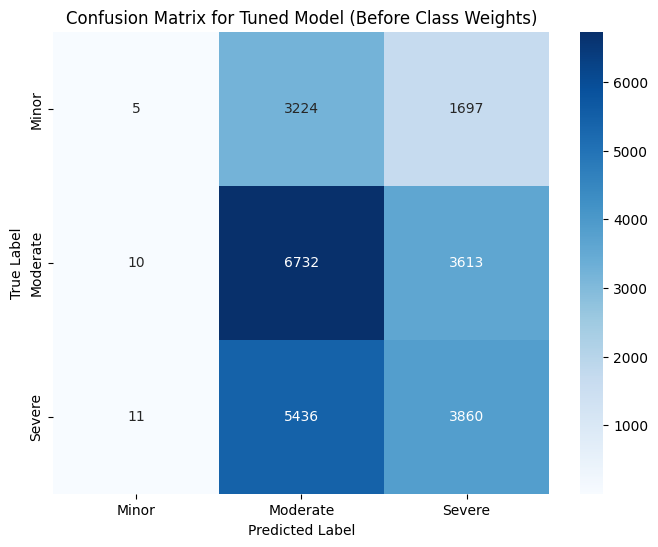

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
save_path = "results/plots/"
os.makedirs(save_path, exist_ok=True)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=severity_order, yticklabels=severity_order)
plt.title('Confusion Matrix for Tuned Model (Before Class Weights)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(f"{save_path}confusion_matrix_tuned_model_before_class_weights.png", dpi=150, bbox_inches="tight")
plt.show()

## 10.2 Interpretation of Model Performance (Tuned Model)

The evaluation metrics from the classification report and confusion matrix provide critical insights into the `model_tuned`'s performance on the validation set:

#### Overall Accuracy
*   The model achieved an overall **accuracy of 0.43 (43%)** on the validation set. This is a low accuracy, suggesting significant room for improvement.

#### Performance by Class
*   **Minor Injuries (Class 0):** This class shows a critical failure point for the model:
    *   **Precision: 0.19**: When the model predicts an injury as 'Minor', it is correct only 19% of the time, indicating many false positives.
    *   **Recall: 0.00**: The model completely fails to identify any actual 'Minor' injuries (out of 4926 actual 'Minor' injuries, only 5 were correctly classified, which is practically zero recall). This means it is unable to detect this class at all.
    *   **F1-score: 0.00**: Reflects the complete failure to recall 'Minor' injuries.
    *   The confusion matrix shows that out of 4926 actual 'Minor' injuries, a negligible 5 were predicted as 'Minor', while 3224 were misclassified as 'Moderate' and 1697 as 'Severe'.

*   **Moderate Injuries (Class 1):**
    *   **Precision: 0.44**: When the model predicts an injury as 'Moderate', it is correct 44% of the time.
    *   **Recall: 0.65**: The model correctly identifies 65% of all actual 'Moderate' injuries.
    *   **F1-score: 0.52**: Indicates a moderate performance for this class.
    *   The confusion matrix shows that out of 10355 actual 'Moderate' injuries, 6732 were correctly predicted as 'Moderate', while 10 were misclassified as 'Minor' and 3613 as 'Severe'.

*   **Severe Injuries (Class 2):**
    *   **Precision: 0.42**: When the model predicts an injury as 'Severe', it is correct 42% of the time.
    *   **Recall: 0.41**: The model correctly identifies 41% of all actual 'Severe' injuries.
    *   **F1-score: 0.42**: Indicates a moderate performance, similar to precision and recall.
    *   The confusion matrix shows that out of 9307 actual 'Severe' injuries, 3860 were correctly predicted as 'Severe', while 11 were misclassified as 'Minor' and 5436 as 'Moderate'.

#### Key Observations and Summary
1.  **Complete Failure for 'Minor' Class**: The most striking observation is the model's absolute inability to predict 'Minor' injuries (0% recall). This is a critical issue that needs immediate attention.
2.  **Bias Towards Higher Severity**: The confusion matrix clearly indicates a strong bias towards predicting 'Moderate' and 'Severe' injuries. Many 'Minor' injuries are misclassified as 'Moderate' or 'Severe', and a significant portion of 'Moderate' injuries are misclassified as 'Severe'.
3.  **Overall Low Performance**: Despite some reasonable recall for 'Moderate' and 'Severe' classes, the overall accuracy of 43% and the complete failure on the 'Minor' class highlight that the model is far from satisfactory.
4.  **Impact of Imbalance**: This performance strongly suggests that the class imbalance is a major factor, leading the model to prioritize the more frequent 'Moderate' and 'Severe' classes at the expense of the minority 'Minor' class.

In conclusion, while hyperparameter tuning was applied, the model's performance, particularly its inability to detect 'Minor' injuries, demonstrates a significant challenge. Addressing the class imbalance is paramount to improving its predictive capabilities across all severity levels.

# Step 11: Calculate Class Weights for Imbalanced Data

Given the severe class imbalance, especially the model's failure to predict 'Minor' injuries, let's calculate class weights. These weights will be used in the model's loss function to give more importance to the underrepresented classes ('Minor') during training, encouraging the model to pay more attention to them.

In [18]:
from sklearn.utils import class_weight
import numpy as np

# Flatten y_train to get all true labels for weight calculation
# Exclude padded values (-1) before calculating weights
y_train_flat_unmasked_actual_labels = y_train[y_train_mask == 1]

# Calculate class weights
# `compute_class_weight` expects a 1D array of class labels
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced', # This mode automatically calculates weights inversely proportional to class frequencies
    classes=np.arange(num_classes),
    y=y_train_flat_unmasked_actual_labels
)

# Convert the array to a dictionary for use in Keras
class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}

print("Calculated Class Weights:")
print(class_weights_dict)


Calculated Class Weights:
{0: np.float64(1.6887660198979504), 1: np.float64(0.7931965918836816), 2: np.float64(0.8717406624383368)}


# Class 12: Recompile and Train Model with Class Weights

Now I will recompile the `model_tuned` (to reset its state before applying class weights) and train it again, this time incorporating the calculated `class_weights_dict` into the `model.fit()` method. This should help the model better learn to predict the 'Minor' class by penalizing its misclassification more heavily.

In [19]:
import tensorflow as tf
import numpy as np

# Recompile the model with the same optimizer and loss (to clear previous training state if any)
model_tuned.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Create a combined sample weight array
# Initialize with zeros (this will mask padded values where y_train_mask is 0)
combined_sample_weights = np.zeros_like(y_train_mask, dtype=float)

# Apply class weights to non-padded values
# We use the original (pre-one-hot) y_train to get the class labels
# Remember that y_train's -1s were changed to 0s for one-hot encoding, so y_train_mask is crucial here.
for i in range(y_train.shape[0]): # Iterate over samples
    for j in range(y_train.shape[1]): # Iterate over timesteps
        if y_train_mask[i, j] == 1: # Only for non-padded values
            class_label = y_train[i, j]
            combined_sample_weights[i, j] = class_weights_dict[class_label]

# Train the new model with EarlyStopping and the combined sample weights
history_weighted = model_tuned.fit(
    X_train,
    y_train_one_hot,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_one_hot, y_val_mask),
    sample_weight=combined_sample_weights, # Use the combined sample weights here
    callbacks=[early_stopping], # Include the EarlyStopping callback
    verbose=1
)
print("Tuned model retraining with EarlyStopping and Class Weights complete.")

Epoch 1/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 75ms/step - accuracy: 0.3619 - loss: 1.0979 - val_accuracy: 0.3374 - val_loss: 1.0995
Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 29s 76ms/step - accuracy: 0.3605 - loss: 1.0947 - val_accuracy: 0.3535 - val_loss: 1.0938
Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.3636 - loss: 1.0943 - val_accuracy: 0.3901 - val_loss: 1.0885
Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.3644 - loss: 1.0929 - val_accuracy: 0.3267 - val_loss: 1.1033
Epoch 5/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.3630 - loss: 1.0933 - val_accuracy: 0.3504 - val_loss: 1.0970
Epoch 6/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.3658 - loss: 1.0924 - val_accuracy: 0.3771 - val_loss: 1.0876
Epoch 7/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.3673 - loss: 1.0924 - val_accuracy: 0.3687 - val_loss: 1.0914
Epoch 8/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.3686 - loss: 1.0922 - 

# Step 13: Evaluate Tuned Model with Class Weights

In [20]:
y_pred_probabilities_weighted = model_tuned.predict(X_val)
print("Predictions on validation set generated for weighted model.")
print(f"Shape of predicted probabilities: {y_pred_probabilities_weighted.shape}")

195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
Predictions on validation set generated for weighted model.
Shape of predicted probabilities: (6238, 14, 3)


Classification Report for Tuned Model (with Class Weights) on Validation Set:

              precision    recall  f1-score   support

       Minor       0.22      0.48      0.30      4926
    Moderate       0.47      0.14      0.22     10355
      Severe       0.42      0.48      0.44      9307

    accuracy                           0.34     24588
   macro avg       0.37      0.37      0.32     24588
weighted avg       0.40      0.34      0.32     24588


Confusion Matrix for Tuned Model (with Class Weights) on Validation Set:

[[2388  574 1964]
 [4605 1475 4275]
 [3794 1079 4434]]


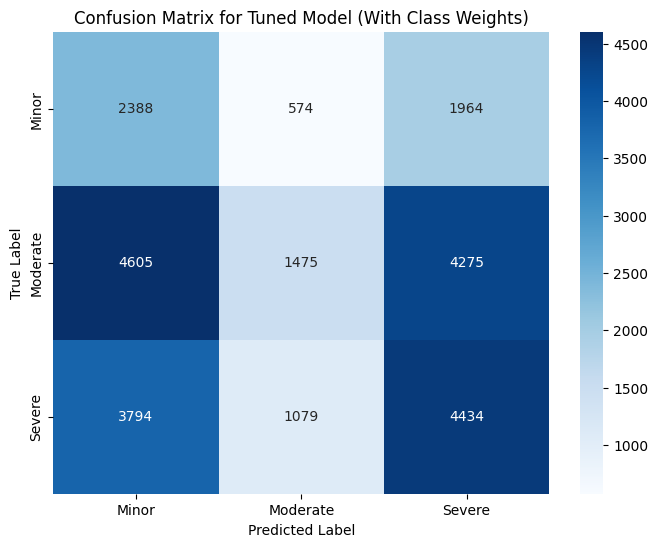

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

save_path = "results/plots/"
os.makedirs(save_path, exist_ok=True)

# Get predicted class labels by taking the argmax of the probabilities
y_pred_classes_weighted = np.argmax(y_pred_probabilities_weighted, axis=-1);

# Flatten the true labels (y_val) and predicted labels (y_pred_classes_weighted) for evaluation
# We need to unmask them first to remove padded values, using y_val_mask

y_true_flat_unmasked = y_val[y_val_mask == 1]
y_pred_flat_unmasked_weighted = y_pred_classes_weighted[y_val_mask == 1]

# Generate classification report
report_weighted = classification_report(
    y_true_flat_unmasked,
    y_pred_flat_unmasked_weighted,
    labels=np.arange(num_classes), # Ensure all classes are represented
    target_names=severity_order,
    zero_division=0
)
print("Classification Report for Tuned Model (with Class Weights) on Validation Set:\n")
print(report_weighted)

# Generate confusion matrix
conf_matrix_weighted = confusion_matrix(y_true_flat_unmasked, y_pred_flat_unmasked_weighted, labels=np.arange(num_classes))
print("\nConfusion Matrix for Tuned Model (with Class Weights) on Validation Set:\n")
print(conf_matrix_weighted)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_weighted, annot=True, fmt='d', cmap='Blues',
            xticklabels=severity_order, yticklabels=severity_order)
plt.title('Confusion Matrix for Tuned Model (With Class Weights)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(f"{save_path}confusion_matrix_tuned_model_with_class_weights.png", dpi=150, bbox_inches="tight")
plt.show()

## 13.1: Interpretation of Model Performance (with Class Weights)

The evaluation results for the model trained with class weights are now available. Let's analyze the classification report and confusion matrix to understand the impact of this change:

### Classification Report for Tuned Model (with Class Weights):
```
              precision    recall  f1-score   support

       Minor       0.22      0.48      0.30      4926
    Moderate       0.47      0.14      0.22     10355
      Severe       0.42      0.48      0.44      9307

    accuracy                           0.34     24588
   macro avg       0.37      0.37      0.32     24588
weighted avg       0.40      0.34      0.32     24588
```

### Confusion Matrix for Tuned Model (with Class Weights):
```
[[2388  574 1964]
 [4605 1475 4275]
 [3794 1079 4434]]
```

### Interpretation of Model Performance (with Class Weights)

Compared to the previous model without class weights:

*   **Minor Injuries (Class 0):** This is where we see the most significant change. Previously, the model never predicted 'Minor' injuries (precision, recall, f1-score were all 0.00). Now, with class weights:
    *   **Recall for Minor is 0.48**: The model is now able to correctly identify 48% of actual 'Minor' injuries, a substantial improvement from 0% before. This is reflected in the confusion matrix where 2388 'Minor' injuries were correctly classified.
    *   **Precision for Minor is 0.22**: However, when the model *does* predict an injury as 'Minor', it's only correct 22% of the time. This suggests it's over-predicting 'Minor' injuries, often misclassifying 'Moderate' and 'Severe' injuries as 'Minor' (see the first column of the confusion matrix: 4605 'Moderate' and 3794 'Severe' injuries were predicted as 'Minor').

*   **Moderate Injuries (Class 1):** Performance has significantly decreased:
    *   **Recall decreased from 0.65 to 0.14**: The model is now less effective at identifying actual 'Moderate' injuries.
    *   **Precision increased from 0.44 to 0.47**.

*   **Severe Injuries (Class 2):** Performance has slightly shifted:
    *   **Recall increased from 0.41 to 0.48**.
    *   **Precision slightly decreased from 0.42 to 0.42**.

*   **Overall Accuracy:** The overall accuracy has **decreased from 0.43 to 0.34**. This is a common trade-off when using class weights to improve recall for a minority class; the model becomes better at identifying the minority class but might do so at the expense of overall accuracy or performance on majority classes.

**Conclusion:**
Applying class weights successfully enabled the model to detect 'Minor' injuries, which it completely missed before. This is a positive step towards addressing the minority class problem. However, this came with a reduction in overall accuracy and a significant decrease in recall for 'Moderate' injuries, and a slight increase in recall for 'Severe'. The model is now more prone to misclassifying 'Moderate' and 'Severe' injuries as 'Minor'.

This indicates that while class weighting helps, further exploration into more sophisticated techniques (like advanced resampling methods, different model architectures, or specialized loss functions for imbalanced data) might be necessary to achieve a better balance between detecting minority classes and maintaining overall good performance across all severity levels.